In [1]:
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np
base_path = Path("/Users/clairenastaskin/data/sub-Forest001/2026-05-06/pathfinder.forest/events/multilocalizer_ffa")
combine_runs_file_path = Path(base_path / "combined_runs")
runs = {
    "run01": Path(base_path / "069fbdc8-2501-746d-8000-b5e1eeef7a62"),
    "run02": Path(base_path / "069fbddf-03a8-70cf-8000-fb5428d52726"),
    "run03": Path(base_path / "069fbdf5-ea5a-72a3-8000-4764054efd54"),      
    "run04": Path(base_path / "069fbe0f-9f62-7fee-8000-c53b03b96419"),
    "run05": Path(base_path / "069fbe2d-59ed-7026-8000-858a51bcf22e"),
}
file_name = 'fusi_run_clean.nii.gz' # Upload runs after temporal boxcar smoothing, 


# Load fUSI nifti file and get data into a numpy array
nifti_img_list = []
fusi_data_list = []
fusi_indices_retained_list = []
mean_run_brain_list = []
mask_list = []  
for run_name, run_path in runs.items():
    # Load fUSI nifti file and get data into a numpy array
    nifti_img = nib.load(run_path / file_name)
    nifti_img_list.append(nifti_img)

    # Get fUSI data as numpy array
    fusi_data = nifti_img.get_fdata()
    print(f"{run_name} : shape", fusi_data.shape)
    fusi_data_list.append(fusi_data)

    # Load retained frame indices for this run
    fusi_indices_retained = np.load(run_path / "fusi_indices_retained_volumes.npy").astype(int)
    print(f"      : {fusi_data.shape[3]} total frames, {len(fusi_indices_retained)} good frames")
    fusi_indices_retained_list.append(fusi_indices_retained)

    mask_path = next(run_path.glob("mask.nii.gz"))
    nifti_mask = nib.load(mask_path)
    mask = nifti_mask.get_fdata()
    mask_list.append(mask)

    # Compute temporal mean using only good frames (fusi_indices_retained)
    mean_run = np.nanmean(fusi_data[:,:,:,fusi_indices_retained], axis=3)
    print(f"      : mean shape", mean_run.shape)
    mean_run_brain = mean_run * mask # Apply brain mask
    mean_run_brain_list.append(mean_run_brain)

run01 : shape (181, 87, 141, 134)
      : 134 total frames, 123 good frames
      : mean shape (181, 87, 141)
run02 : shape (181, 87, 141, 142)
      : 142 total frames, 138 good frames
      : mean shape (181, 87, 141)
run03 : shape (181, 87, 141, 157)
      : 157 total frames, 150 good frames
      : mean shape (181, 87, 141)
run04 : shape (181, 87, 141, 140)
      : 140 total frames, 134 good frames
      : mean shape (181, 87, 141)
run05 : shape (181, 87, 141, 142)
      : 142 total frames, 133 good frames
      : mean shape (181, 87, 141)


In [2]:
import ants
import warnings
from nilearn.image import mean_img, resample_img

def nib_to_ants(nib_img):
    """Convert a nibabel image to an ANTs image."""
    data = nib_img.get_fdata().astype(np.float32)
    affine = nib_img.affine
    img = ants.from_numpy(data)
    img.set_direction(affine[:3, :3] / np.abs(affine[:3, :3]).max(axis=0))
    img.set_origin(affine[:3, 3].tolist())
    img.set_spacing(np.abs(np.diag(affine[:3, :3])).tolist())
    return img


run_names = list(runs.keys())

# Reference: first run
fixed = nib_to_ants(nib.Nifti1Image(mean_run_brain_list[0], nifti_img_list[0].affine))

# Rigid registration with mutual information (robust to intensity differences)
# Compute one transform per non-reference run
print("Running rigid registrations with mutual information...")
fwd_transforms_list = []  # parallel to runs[1:]
for run_idx in range(1, len(runs)):
    moving = nib_to_ants(nib.Nifti1Image(mean_run_brain_list[run_idx], nifti_img_list[run_idx].affine))
    print(f"  Registering {run_names[run_idx]} -> {run_names[0]}...")
    reg = ants.registration(
        fixed=fixed,
        moving=moving,
        type_of_transform='Rigid',
        aff_metric='mattes',
    )
    fwd_transforms_list.append(reg['fwdtransforms'])
print("Registration complete.")


# Apply each per-run transform to every good timepoint (skip the reference)
print("Applying transforms to good frames of runs to register...")
fusi_registered_list = []
for i, run_idx in enumerate(range(1, len(runs))):
    print(f"Processing {run_names[run_idx]}...")
    fusi_to_register = fusi_data_list[run_idx]
    fusi_to_register = np.nan_to_num(fusi_to_register[:, :, :, fusi_indices_retained_list[run_idx]])
    registered_frames = []
    for t in range(fusi_to_register.shape[3]):
        frame = nib_to_ants(nib.Nifti1Image(fusi_to_register[:, :, :, t], nifti_img_list[run_idx].affine))
        warped = ants.apply_transforms(fixed, frame, fwd_transforms_list[i])
        registered_frames.append(warped.numpy())
    fusi_data_registered = np.stack(registered_frames, axis=3)
    fusi_registered_list.append(fusi_data_registered)
    print(f"Registered {run_names[run_idx]} shape: {fusi_data_registered.shape}")


# Subsample reference run to good frames only
fusi_data_ref_good = np.nan_to_num(fusi_data_list[0][:, :, :, fusi_indices_retained_list[0]])

# Build NIfTI images for GLM (subsampled to match design matrices)
fusi_img = [nib.Nifti1Image(fusi_data_ref_good, nifti_img_list[0].affine, nifti_img_list[0].header)]
for i, run_idx in enumerate(range(1, len(runs))):
    fusi_img.append(
        nib.Nifti1Image(fusi_registered_list[i], nifti_img_list[run_idx].affine, nifti_img_list[run_idx].header)
    )


# Save
combine_runs_file_path.mkdir(parents=True, exist_ok=True)
for run_idx in range(len(runs)):
    nib.save(fusi_img[run_idx], combine_runs_file_path / f'{run_names[run_idx]}_registered_clean.nii.gz')
print(f"Saved all registered runs to {combine_runs_file_path}")

Running rigid registrations with mutual information...
  Registering run02 -> run01...
  Registering run03 -> run01...
  Registering run04 -> run01...
  Registering run05 -> run01...
Registration complete.
Applying transforms to good frames of runs to register...
Processing run02...
Registered run02 shape: (181, 87, 141, 138)
Processing run03...
Registered run03 shape: (181, 87, 141, 150)
Processing run04...
Registered run04 shape: (181, 87, 141, 134)
Processing run05...
Registered run05 shape: (181, 87, 141, 133)
Saved all registered runs to /Users/clairenastaskin/data/sub-Forest001/2026-05-06/pathfinder.forest/events/multilocalizer_ffa/combined_runs


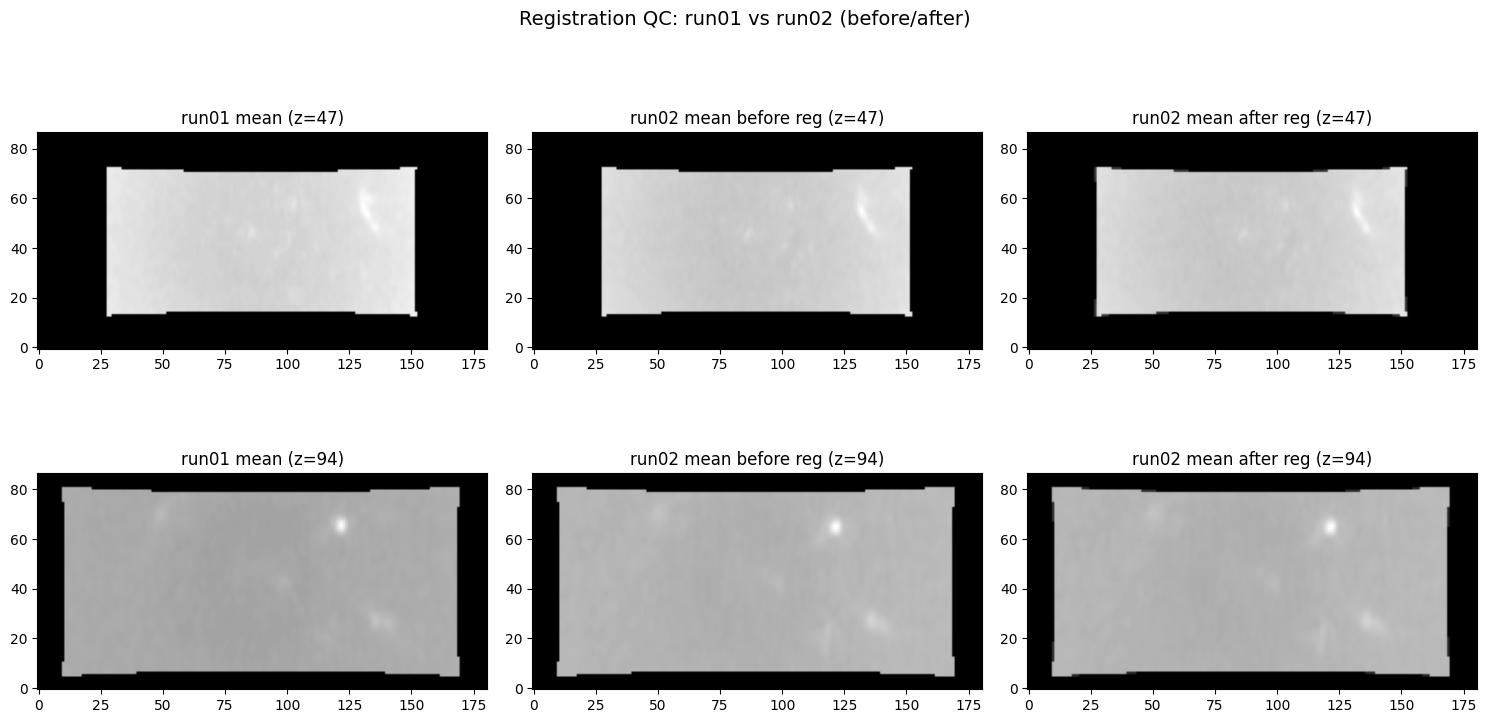

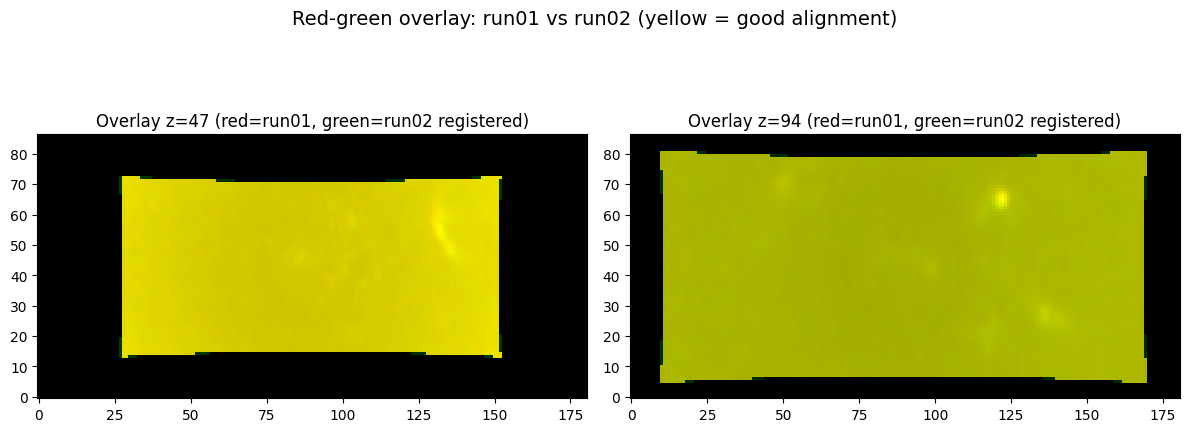

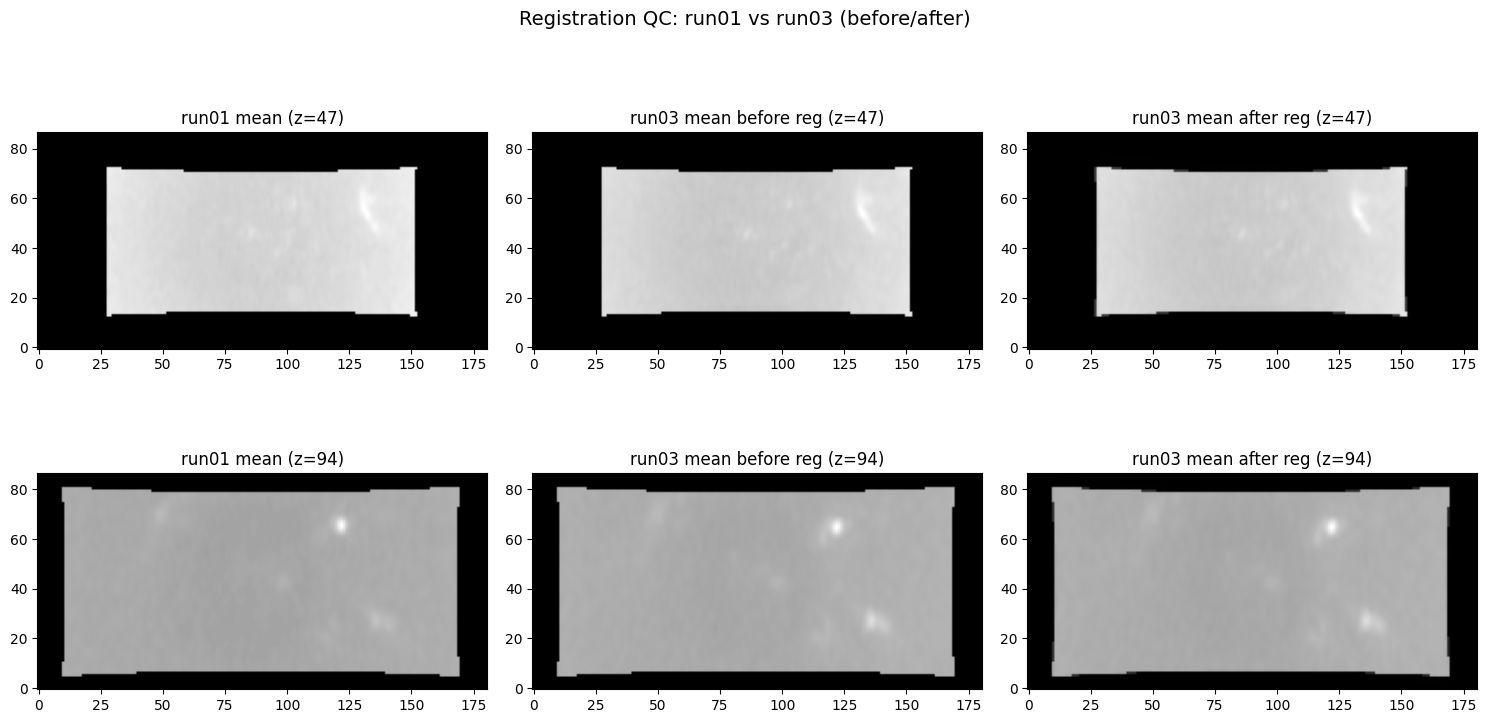

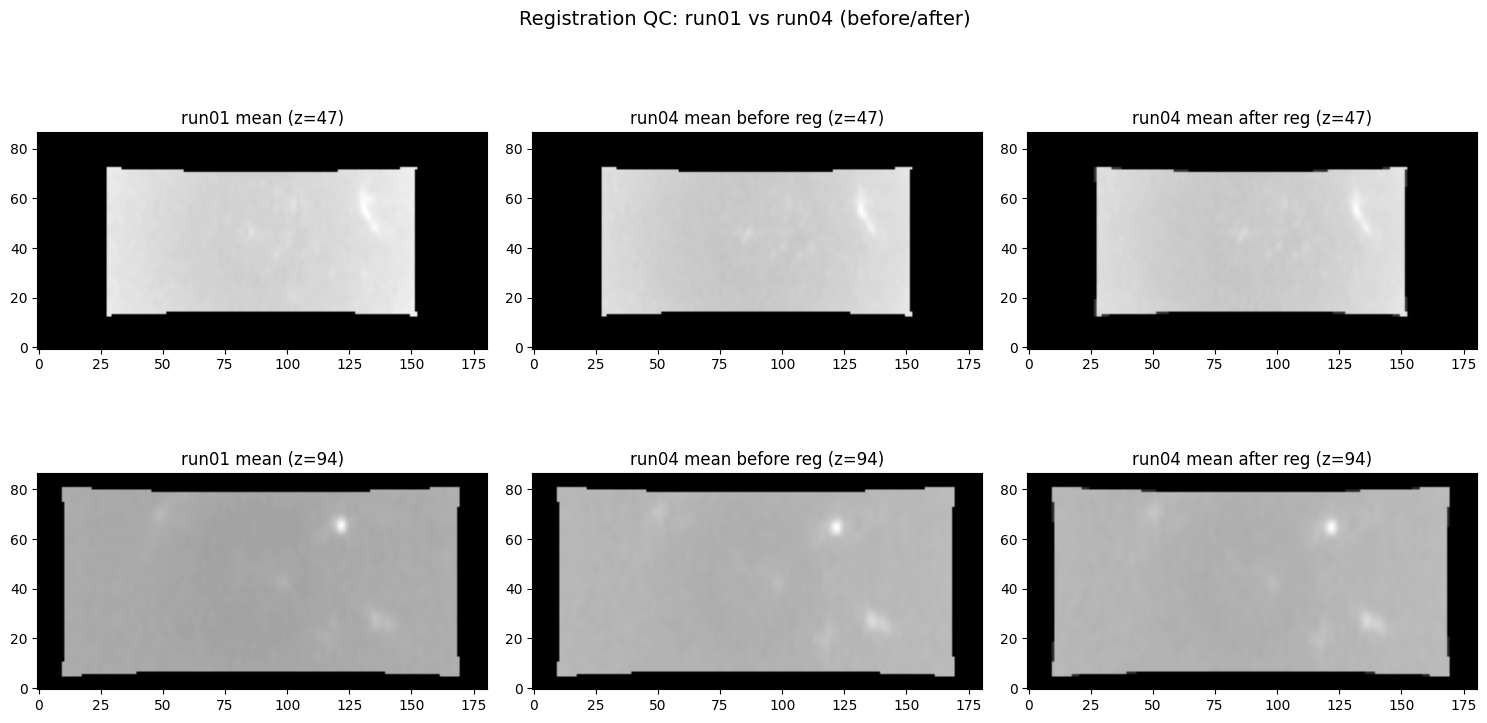

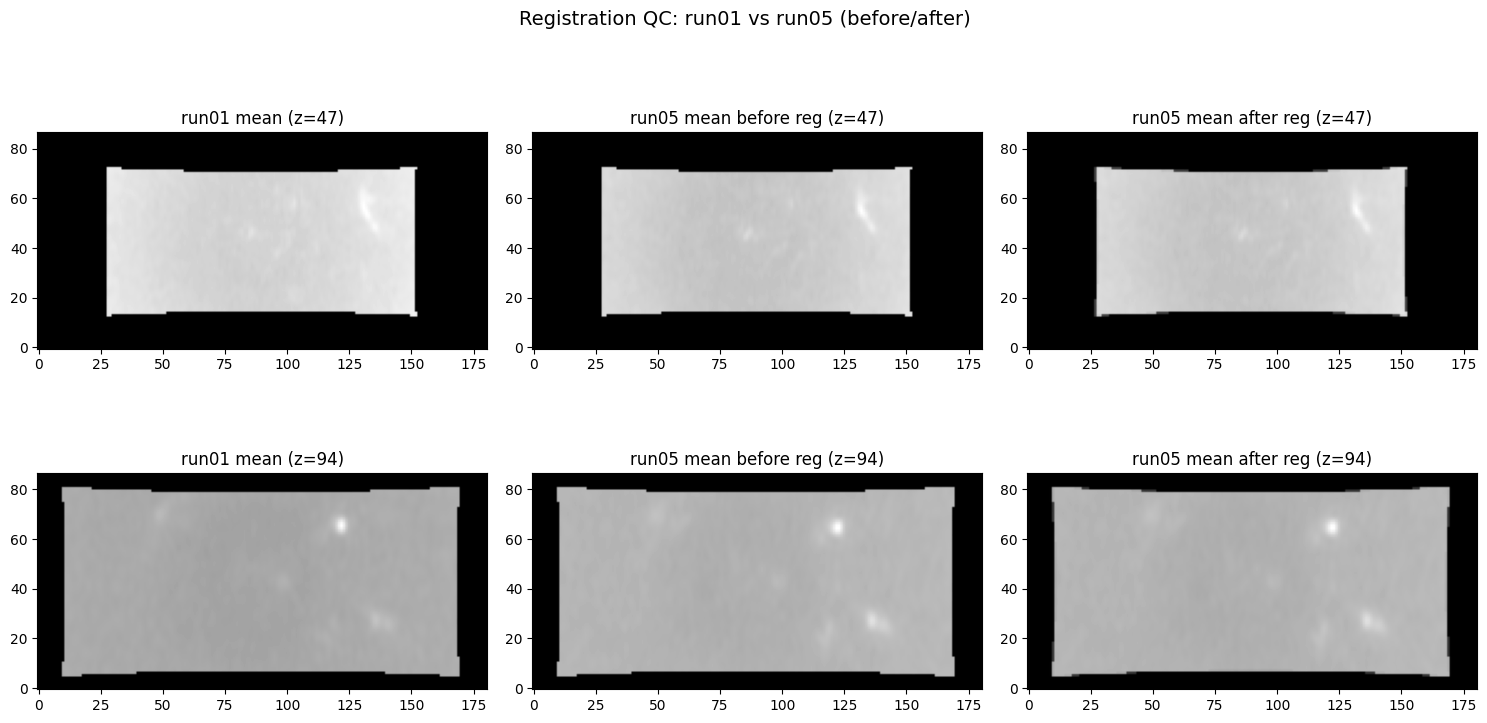

In [ ]:
import matplotlib.pyplot as plt

# Compute mean of each registered run for comparison
mean_runs_registered = [np.mean(reg, axis=3) for reg in fusi_registered_list]

# Pick two slices along the z-axis (elevation) for visualization
z_slices = [fusi_data_list[0].shape[2] // 3, 2 * fusi_data_list[0].shape[2] // 3]

# One QC figure per registered run (compared against the reference run)
for i, mean_run_registered in enumerate(mean_runs_registered):
    run_idx = i + 1  # fusi_registered_list[0] corresponds to runs index 1
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for row, z in enumerate(z_slices):
        axes[row, 0].imshow(mean_run_brain_list[0][:, :, z].T, cmap='gray', origin='lower')
        axes[row, 0].set_title(f'{run_names[0]} mean (z={z})')

        axes[row, 1].imshow(mean_run_brain_list[run_idx][:, :, z].T, cmap='gray', origin='lower')
        axes[row, 1].set_title(f'{run_names[run_idx]} mean before reg (z={z})')

        axes[row, 2].imshow(mean_run_registered[:, :, z].T, cmap='gray', origin='lower')
        axes[row, 2].set_title(f'{run_names[run_idx]} mean after reg (z={z})')

    plt.suptitle(f'Registration QC: {run_names[0]} vs {run_names[run_idx]} (before/after)', fontsize=14)
    plt.tight_layout()
    plt.show()

    if i==0 & run_idx == 1:  # Only show overlay for the first registered run for brevity
        # Overlay: reference in red, registered moving in green
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for col, z in enumerate(z_slices):
            r = mean_run_brain_list[0][:, :, z].T.copy()
            g = mean_run_registered[:, :, z].T.copy()
            r = (r - r.min()) / (r.max() - r.min() + 1e-8)
            g = (g - g.min()) / (g.max() - g.min() + 1e-8)
            overlay = np.stack([r, g, np.zeros_like(r)], axis=-1)
            axes[col].imshow(overlay, origin='lower')
            axes[col].set_title(f'Overlay z={z} (red={run_names[0]}, green={run_names[run_idx]} registered)')

        plt.suptitle(f'Red-green overlay: {run_names[0]} vs {run_names[run_idx]} (yellow = good alignment)', fontsize=14)
        plt.tight_layout()
        plt.show()

In [4]:
mean_image = mean_img(fusi_img, copy_header=True)
print(f"Mean image shape: {mean_image.shape}")

Mean image shape: (181, 87, 141)


In [5]:
# repetition time, in seconds (loaded from the first run)
first_run_path = next(iter(runs.values()))
t_r = float(np.load(first_run_path / 't_r.npy'))
# Sample at the beginning of each acquisition.
slice_time_ref = 0.0
# We use a discrete cosine transform to model signal drifts.
drift_model = "Cosine"
# The cutoff for the drift model is 0.01 Hz.
high_pass = 0.01
# The hemodynamic response function
hrf_model = "spm + derivative"

In [12]:
import numpy as np
import pandas as pd
from numpy import load
from nilearn.glm.first_level import make_first_level_design_matrix

# Load design matrices with reaction time taken into account already
design_matrices = []
for run_name, run_path in runs.items():
    dm_npz = load(run_path / 'design_matrix_auditory.npz', allow_pickle=True)
    dm = pd.DataFrame(dm_npz['design_matrix'], columns=dm_npz['column_names'])
    design_matrices.append(dm)

for i, dm in enumerate(design_matrices, 1):
    print(f"Design matrix {i} shape: {dm.shape}")

Design matrix 1 shape: (123, 35)
Design matrix 2 shape: (138, 35)
Design matrix 3 shape: (150, 36)
Design matrix 4 shape: (134, 35)
Design matrix 5 shape: (133, 35)


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_57960/329872991.py:7: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(dm, ax=axes[0, i])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_57960/329872991.py:7: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(dm, ax=axes[0, i])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_57960/329872991.py:7: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(dm, ax=axes[0, i])
/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_57960/329872991.py:7: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(dm, ax=axes[0, i])
/var/folders

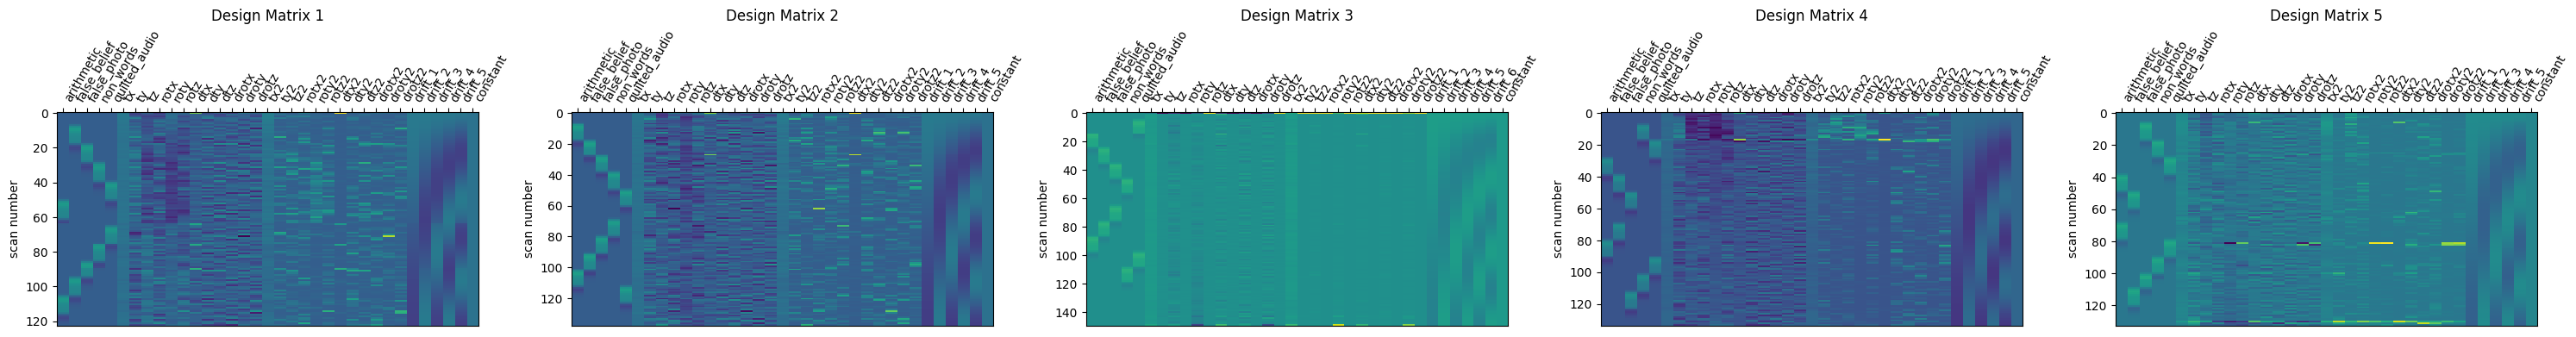

In [13]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix

n_runs = len(design_matrices)
fig, axes = plt.subplots(1, n_runs, figsize=(6 * n_runs, 4), squeeze=False)
for i, dm in enumerate(design_matrices):
    plot_design_matrix(dm, ax=axes[0, i])
    axes[0, i].set_title(f'Design Matrix {i + 1}')
plt.tight_layout()
fig.show()

In [ ]:
##########################################
## Create contrasts for localizer task ##
##########################################

# EMFL contrasts. Each maps a contrast name to {condition_name: weight}; a
# contrast is skipped if a referenced condition is absent from the design matrix.
# Condition names are the lower-cased enum values from `marvi2025_screen_record`.
VISUAL_CONTRASTS = {
    # Fusiform / occipital face areas (FFA, OFA, pSTS-faces).
    "faces-vs-objects": {"faces": 1.0, "objects": -1.0},
    # Parahippocampal / retrosplenial / occipital place areas (PPA, RSC/MPA, OPA).
    "scenes-vs-objects": {"scenes": 1.0, "objects": -1.0},
    # Extrastriate / fusiform body areas (EBA, FBA).
    "bodies-vs-objects": {"bodies": 1.0, "objects": -1.0},
    # Visual word form area (VWFA) -- words-on-scrambled-objects vs objects.
    "words-vs-objects": {"words_scrambled": 1.0, "objects": -1.0},
}

AUDITORY_CONTRASTS = {
    # Theory-of-mind network (RTPJ, LTPJ, PC, DMPFC; Saxe localizer).
    "falsebelief-vs-falsephoto": {"false_belief": 1.0, "false_photo": -1.0},
    # Language network: intelligible narratives vs acoustically-matched controls.
    "narratives-vs-degraded": {
        "false_belief": 0.5,
        "false_photo": 0.5,
        "non_words": -0.5,
        "quilted_audio": -0.5,
    },
    # Multiple-demand network proxy: arithmetic vs narratives.
    "arithmetic-vs-narratives": {
        "arithmetic": 1.0,
        "false_belief": -0.5,
        "false_photo": -0.5,
    },
    # Auditory cortex: all sounds vs the implicit fixation baseline.
    "sound-vs-baseline": {
        "false_belief": 0.2,
        "false_photo": 0.2,
        "non_words": 0.2,
        "quilted_audio": 0.2,
        "arithmetic": 0.2,
    },
}


def find_all_localizer_contrasts(design_matrices):
    contrast_list = []
    contrasts = []

    for i in range(len(design_matrices)):
        # Get column names excluding motion parameters and drifts
        contrast = [col for col in design_matrices[i].columns 
                    if not col.startswith(('rot', 'drift')) 
                    and col not in ['constant', 'tx', 'ty', 'tz']]
        contrasts.append(contrast)
        
        # Add unique names to overall contrast list
        contrast_list.extend([c for c in contrast if c not in contrast_list])

    contrast_matrix = np.eye(len(contrast_list))
    contrasts = {
        column: contrast_matrix[i]
        for i, column in enumerate(contrast_list)
    }
    return contrasts


def build_visual_contrast_expressions(visual_contrasts, design_matrices):
    """Build nilearn string contrast expressions (e.g. '1.0*faces + -1.0*objects').

    Skips any contrast whose referenced conditions are not present in every
    design matrix — nilearn would otherwise fail to evaluate the expression
    on the run(s) missing those columns. Works for any contrast-name -> {cond: weight}
    mapping (e.g. VISUAL_CONTRASTS, AUDITORY_CONTRASTS).
    """
    available_everywhere = set(design_matrices[0].columns)
    for dm in design_matrices[1:]:
        available_everywhere &= set(dm.columns)

    composite = {}
    for name, weights in visual_contrasts.items():
        missing = [cond for cond in weights if cond not in available_everywhere]
        if missing:
            print(f"  Skipping '{name}' — missing in at least one DM: {missing}")
            continue
        expr = " + ".join(f"{w}*{cond}" for cond, w in weights.items())
        composite[name] = expr
    return composite


contrasts = find_all_localizer_contrasts(design_matrices)
contrasts.update(build_visual_contrast_expressions(VISUAL_CONTRASTS, design_matrices))
contrasts.update(build_visual_contrast_expressions(AUDITORY_CONTRASTS, design_matrices))
print(contrasts)

In [15]:
from nilearn import plotting
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
# Load TR from the first run
first_run_path = next(iter(runs.values()))
t_r = float(np.load(first_run_path / 't_r.npy'))
print(f"TR loaded: {t_r} seconds")

fusi_glm = FirstLevelModel(
        t_r=t_r, minimize_memory=True, hrf_model="glover", drift_model="cosine",
        high_pass=0.01, noise_model="ar1", standardize=True,
        smoothing_fwhm=2, mask_img=nifti_mask)

fusi_glm = fusi_glm.fit(fusi_img, design_matrices=design_matrices)

Fitting a GLM
TR loaded: 2.009744271631579 seconds


	contrast id: arithmetic


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_57960/2714164520.py:12: UserWarning: One contrast given, assuming it for all 5 runs
  z_map = fusi_glm.compute_contrast(contrast_val, output_type="z_score")
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=35, but it has length 20. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/contrasts.py:115: UserWarning: t contrasts should be of length P=36, but it has length 20. The rest of the contrast was padded with zeros.
  reg = regression_result[label_].Tcontrast(con_val)


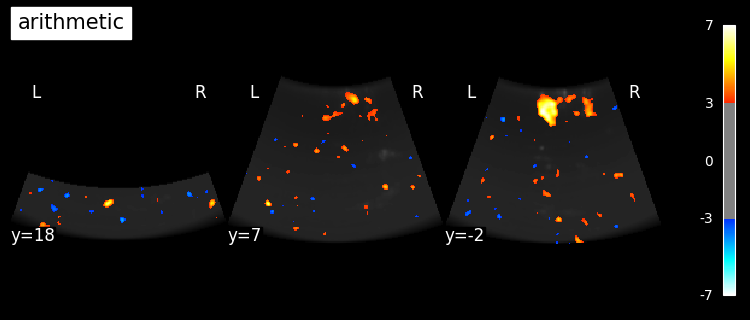

	contrast id: false_belief


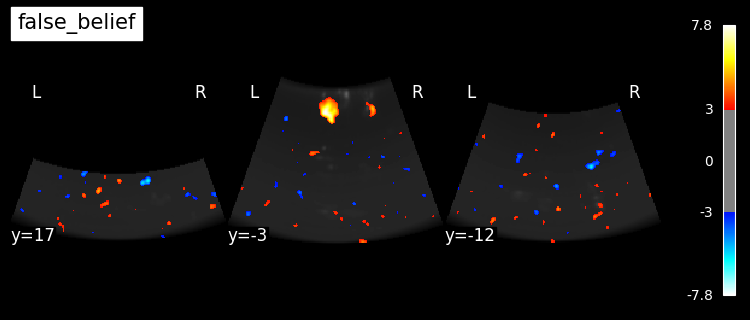

	contrast id: false_photo


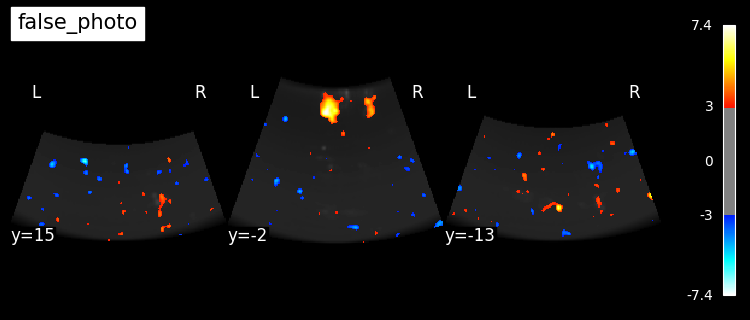

	contrast id: non_words


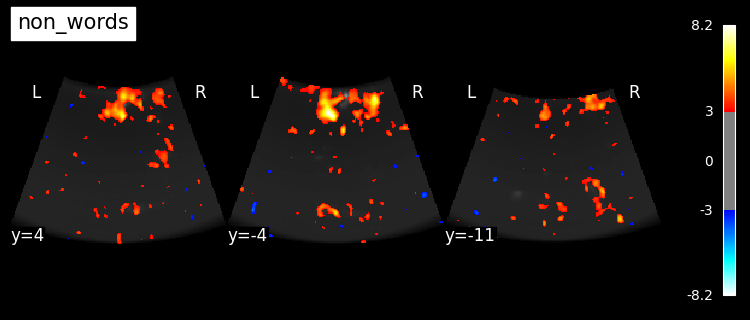

	contrast id: quilted_audio


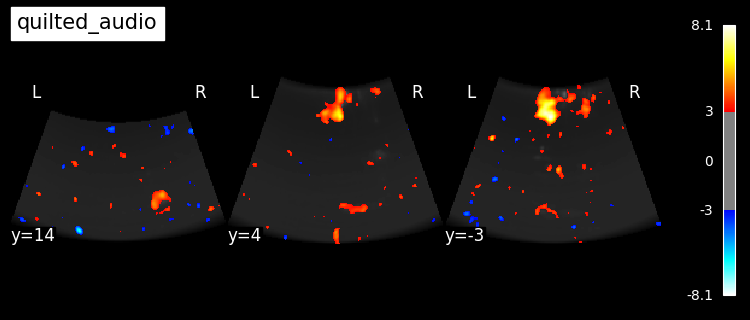

In [16]:
import os

affine_global = nifti_img_list[0].affine

# Iterate on contrasts
for contrast_id, contrast_val in contrasts.items():
    if contrast_id.startswith(("drift_", "tx", "ty", "tz", "rot", "dt", "drot")):
        continue

    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fusi_glm.compute_contrast(contrast_val, output_type="z_score")
    # Get the data from z_map and create new NIfTI image
    z_map_data = z_map.get_fdata()
    nii_zmap = nib.Nifti1Image(z_map_data, affine_global)
    # Save the NIfTI zmap to a compressed .nii.gz file in the base_path
    nii_output_path = os.path.join(combine_runs_file_path, f"{contrast_id}_z_map.nii.gz")
    nib.save(nii_zmap, nii_output_path)

    # Plot the z-map and save a PNG preview next to the NIfTI
    display = plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=3.0,
        display_mode="y",
        cut_coords=3,
        black_bg=True,
        title=contrast_id,
    )
    png_output_path = os.path.join(combine_runs_file_path, f"{contrast_id}_z_map.png")
    display.savefig(png_output_path)
    plotting.show()